# [LAB 06] 데이터 시각화 - 11. 100% Stacked Bar Plot (분할 막대 그래프)

## #01. 준비 작업 

### 1. 라이브러리 불러오기 

In [1]:
from jussam import load_data
from helpers import *
from pandas import pivot_table
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 셋 불러오기 

In [2]:
origin = load_data("region_jobs")
origin

📚 지역별 산업 종사자 수를 조사한 가상의 데이터


,지역,산업,종사자 수
0,서울,서비스업,520
1,부산,서비스업,340
2,대구,서비스업,280
3,인천,서비스업,310
4,서울,제조업,180
5,부산,제조업,220
6,대구,제조업,160
7,인천,제조업,140
8,서울,IT산업,260
9,부산,IT산업,110


### 3. 데이터 전처리 (1) - 피벗 테이블 구성 

In [3]:
## 데이터 피벗팅 (fill_value=0 --> 결측치를 0으로 채움)
df = pivot_table(origin, index="지역", columns="산업",
                 values="종사자 수", aggfunc=np.sum, fill_value=0)

# 인덱스를 문자열 카테고리로 변환
df.index = df.index.astype('str').astype('category')

df

산업,IT산업,서비스업,제조업
지역,,,
대구,90,280,160
부산,110,340,220
서울,260,520,180
인천,150,310,140


### 4. 데이터 전처리 (2) - 절대값을 백분율로 변경하기 위해 총 합계 구하기 

In [4]:
df['sum'] = df.sum(axis=1)
df

산업,IT산업,서비스업,제조업,sum
지역,,,,
대구,90,280,160,530
부산,110,340,220,670
서울,260,520,180,960
인천,150,310,140,600


### 5. 데이터 전처리 (3) - 각 컬럼의 값을 백분율로 변환하고 총 합계 제거 

In [5]:
for col in df.columns: 
    df[col] = df[col] / df['sum'] * 100

df.drop('sum', axis=1, inplace=True)
df

산업,IT산업,서비스업,제조업
지역,,,
대구,16.981,52.830,30.189
부산,16.418,50.746,32.836
서울,27.083,54.167,18.750
인천,25.000,51.667,23.333


## #02. 분할 막대 그래프 

### 1. 누적 막대 그래프에서 데이터셋만 변경된 형태(1/2)

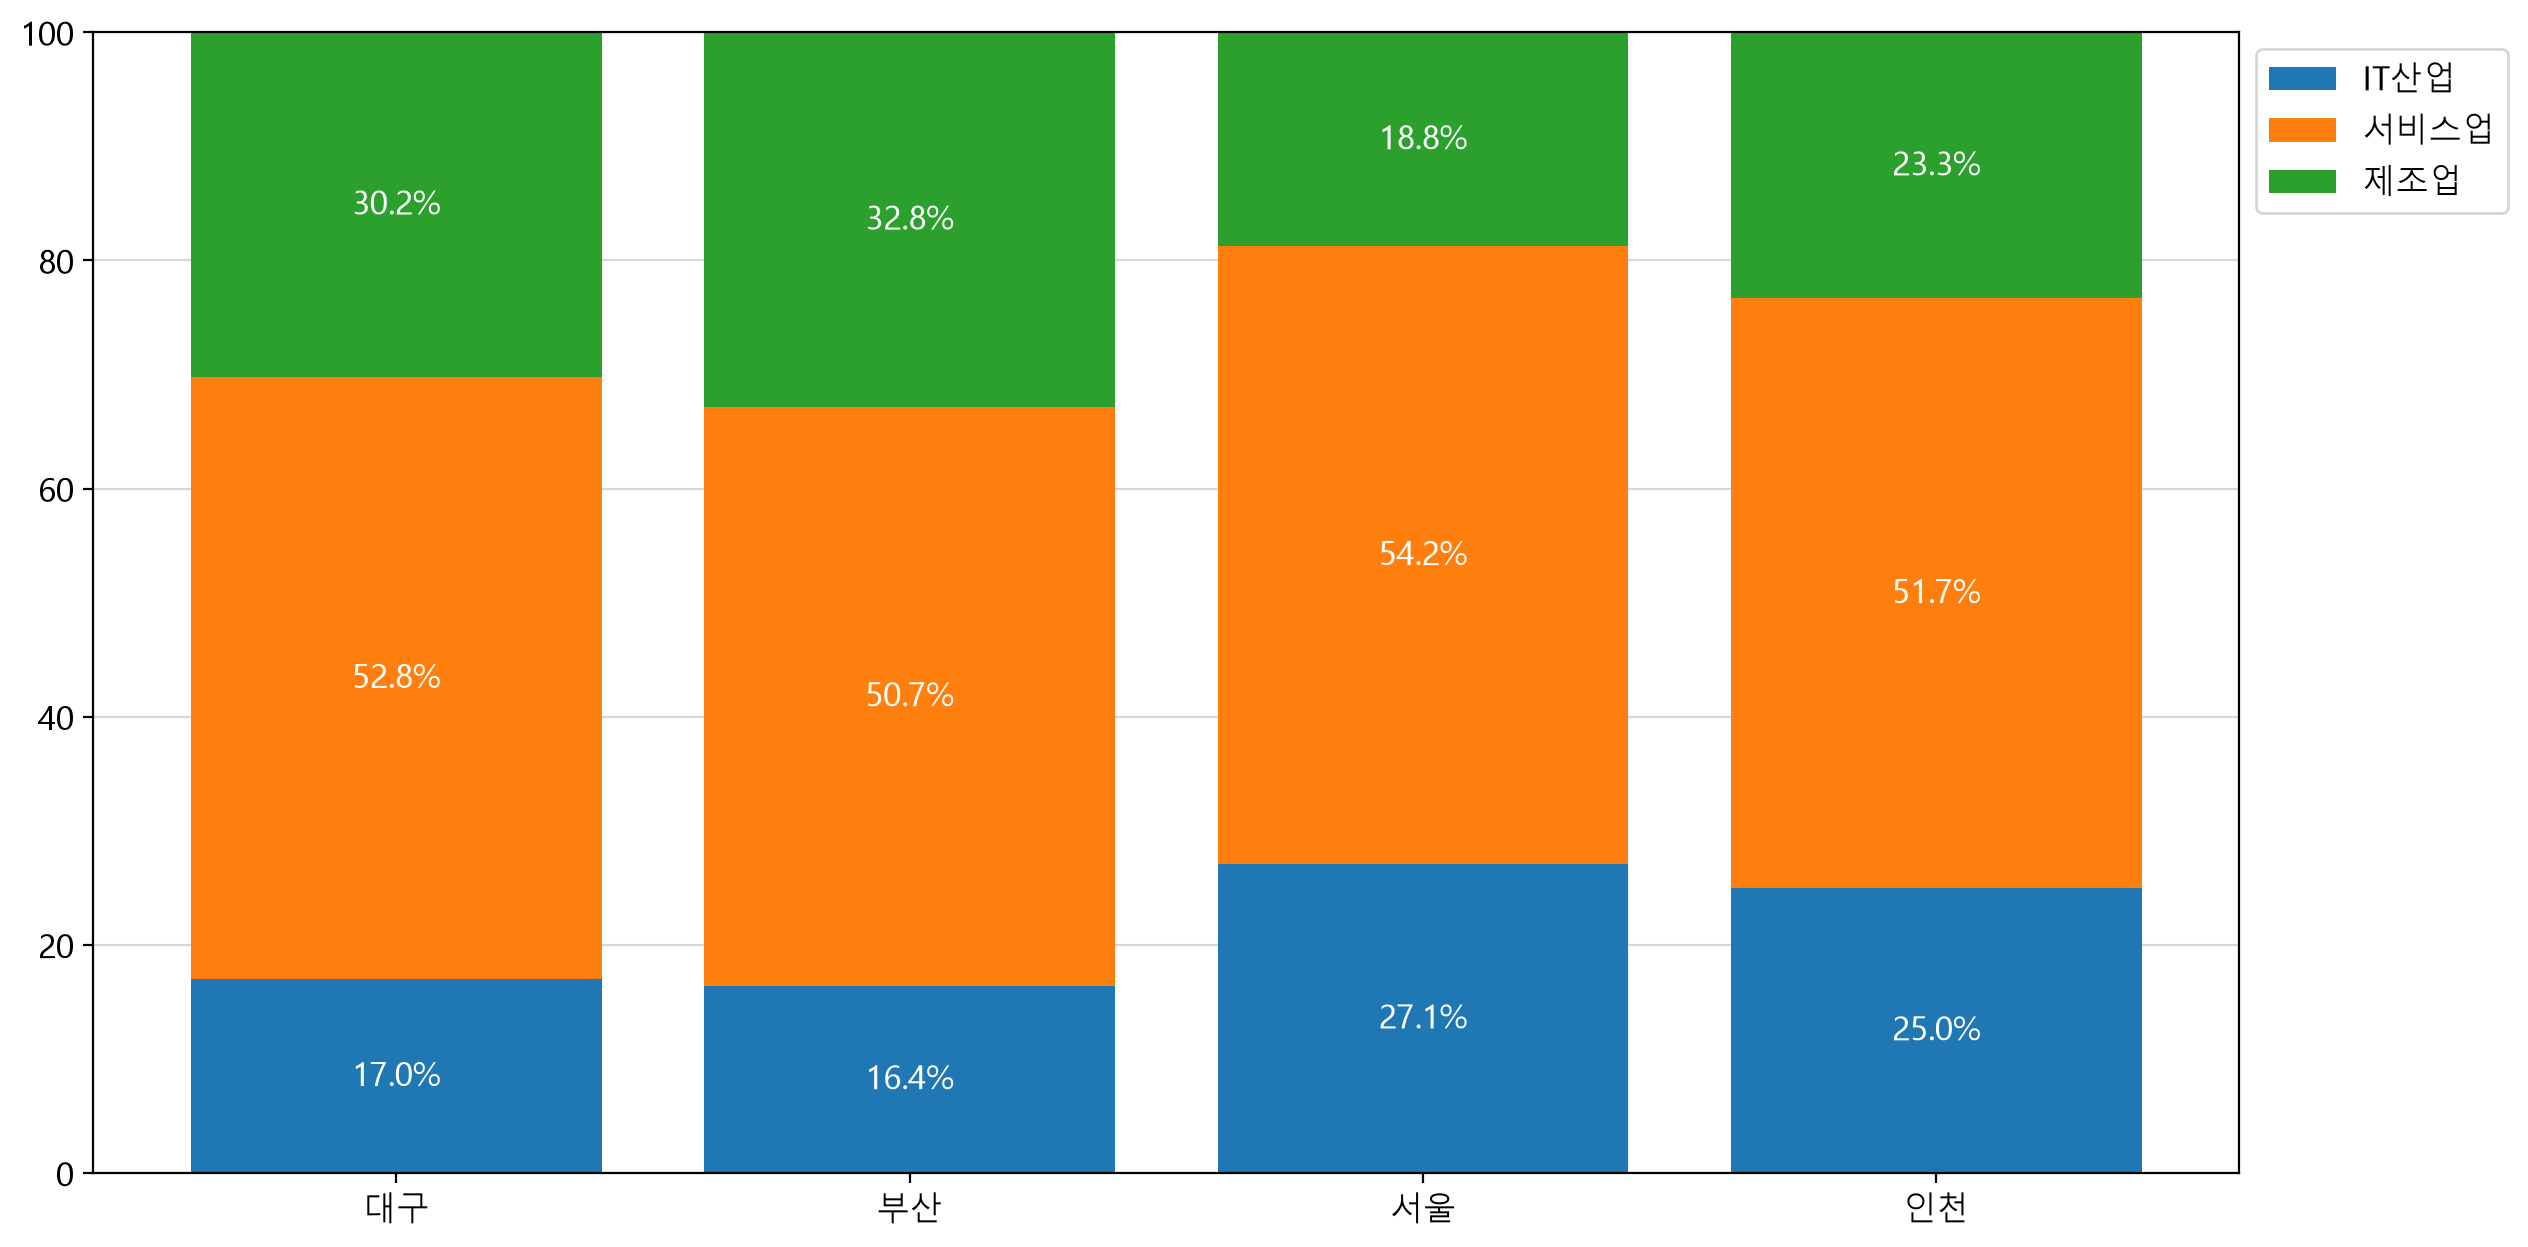

In [6]:
fig, ax = my_plot.init()

# 지역별 IT 산업 종사자 수에 대한 기본 막대 그래프 
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시 
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.bar(df.index, df['제조업'], bottom=df['IT산업']+df['서비스업'], label='제조업')

# 기본 막대 그래프와 누적 막대 그래프에 대한 범례 추가 
# --> bbox_to_anchor= (1,1) : 범주의 위치 오른쪽(1) 상단(1)
# --> bbox_to_anchor= (0,0) : 범주 위치 왼쪽(0) 하단(0)
ax.legend(bbox_to_anchor=(1,1))

# y축 범위를 0에서 100으로 설정 
ax.set_ylim(0,100)

# 텍스트 형식 
text_format = '{:.1f}%'

# 각 막대 위에 종사자 수 표시 
for i in df.index : 
    ax.text(x=i, y=df['IT산업'][i]/2,
            s=text_format.format(df['IT산업'][i]),
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i]/2,
            s=text_format.format(df['서비스업'][i]),
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i]+ df['제조업'][i]/2,
            s=text_format.format(df['제조업'][i]),
            ha='center', va='center', color='white', fontsize=12)
            
my_plot.show()

## #03. 팔레트를 적용한 가로 분할 막대 그래프 

### 1. seaborn의 팔레트에서 범주의 종류 수 만큼 색상 추출 

In [7]:
# seaborn 의 pastel color palette 사용 
colors = sb.color_palette("Set2", 3)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549)]

### 2. 가로 분할 막대 그래프 (1/2)


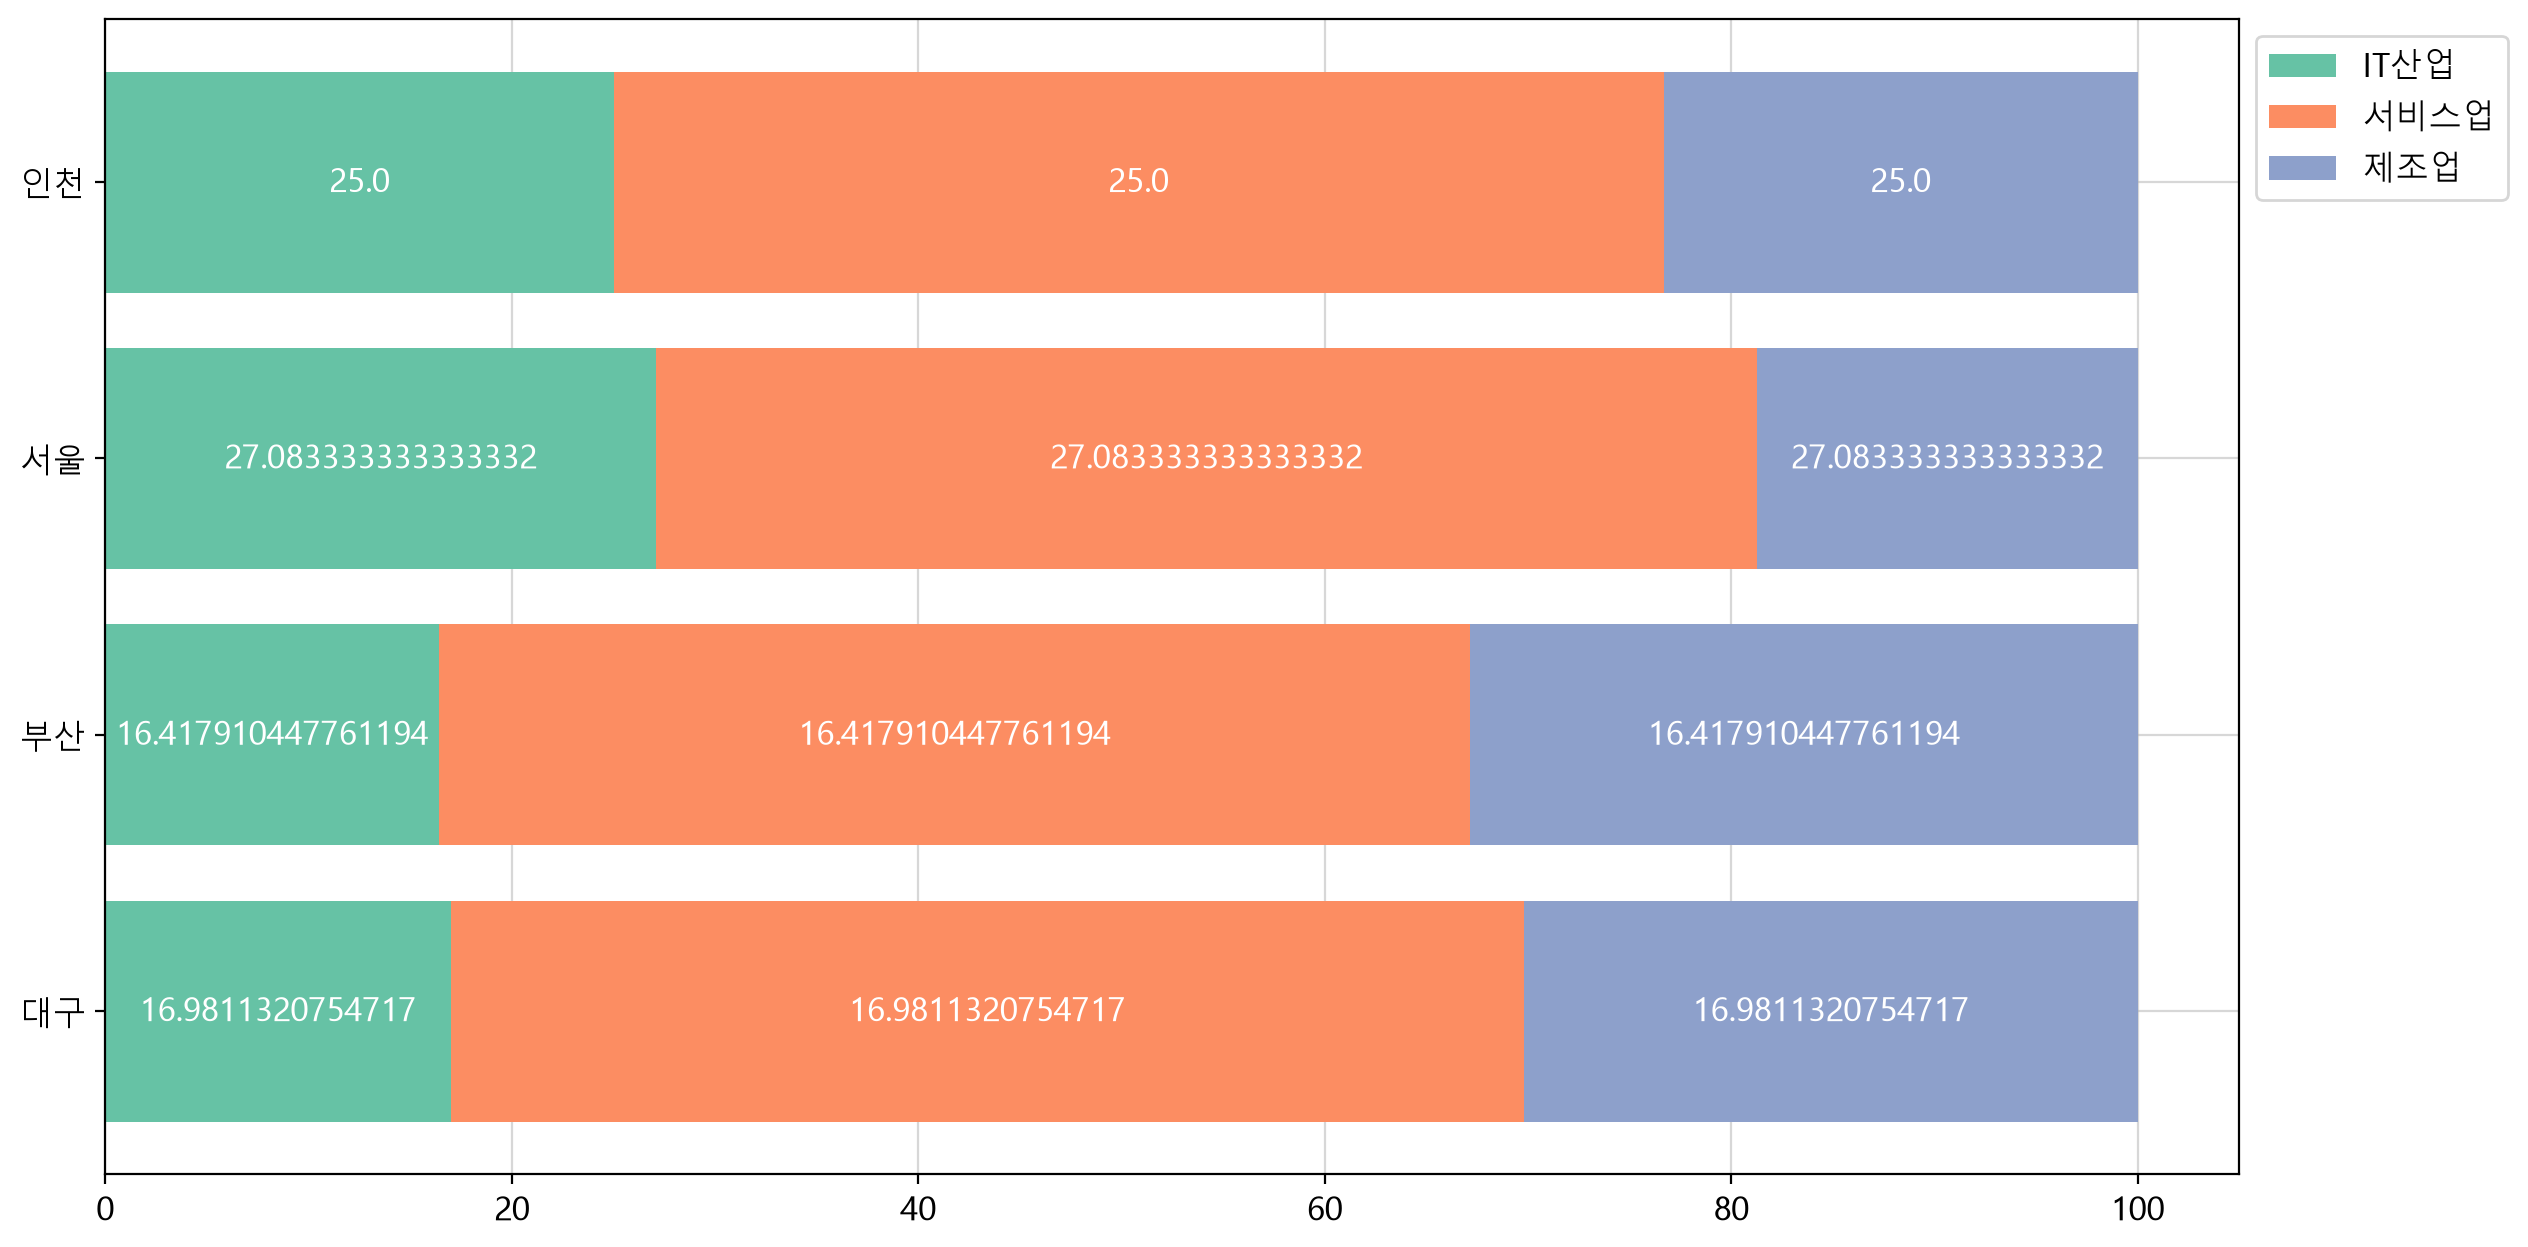

In [8]:
fig, ax = my_plot.init()

# 지역별 IT 산업 종사자 수에 대한 기본 막대 그래프 
ax.barh(df.index, df['IT산업'], label='IT산업', color=colors[0])

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시 
ax.barh(df.index, df['서비스업'], left=df['IT산업'], label='서비스업', color=colors[1])

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.barh(df.index, df['제조업'], left=df['IT산업']+df['서비스업'], label='제조업',
        color=colors[2])

# 기본 막대 그래프와 누적 막대 그래프에 대한 범례 추가 
# --> bbox_to_anchor= (1,1) : 범주의 위치 오른쪽(1) 상단(1)
# --> bbox_to_anchor= (0,0) : 범주 위치 왼쪽(0) 하단(0)
ax.legend(bbox_to_anchor=(1,1))

# 텍스트 형식 
text_format = '{:.1f}%'

# 각 막대 위에 종사자 수 표시 
for i in df.index: 
    ax.text(x=df['IT산업'][i]/2, y=i, 
            s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12
            )
    ax.text(x=df['IT산업'][i] + df['서비스업'][i]/2, y=i, 
            s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12
            ) 
    ax.text(x=df['IT산업'][i] +df['서비스업'][i]+ df['제조업'][i]/2 , y=i, 
            s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12
            )       

my_plot.show()

## #04. 모듈화 기능 확인 

### 1. 가로 분할 막대 그래프 

findfont: Failed to find font weight 500, now using 400.


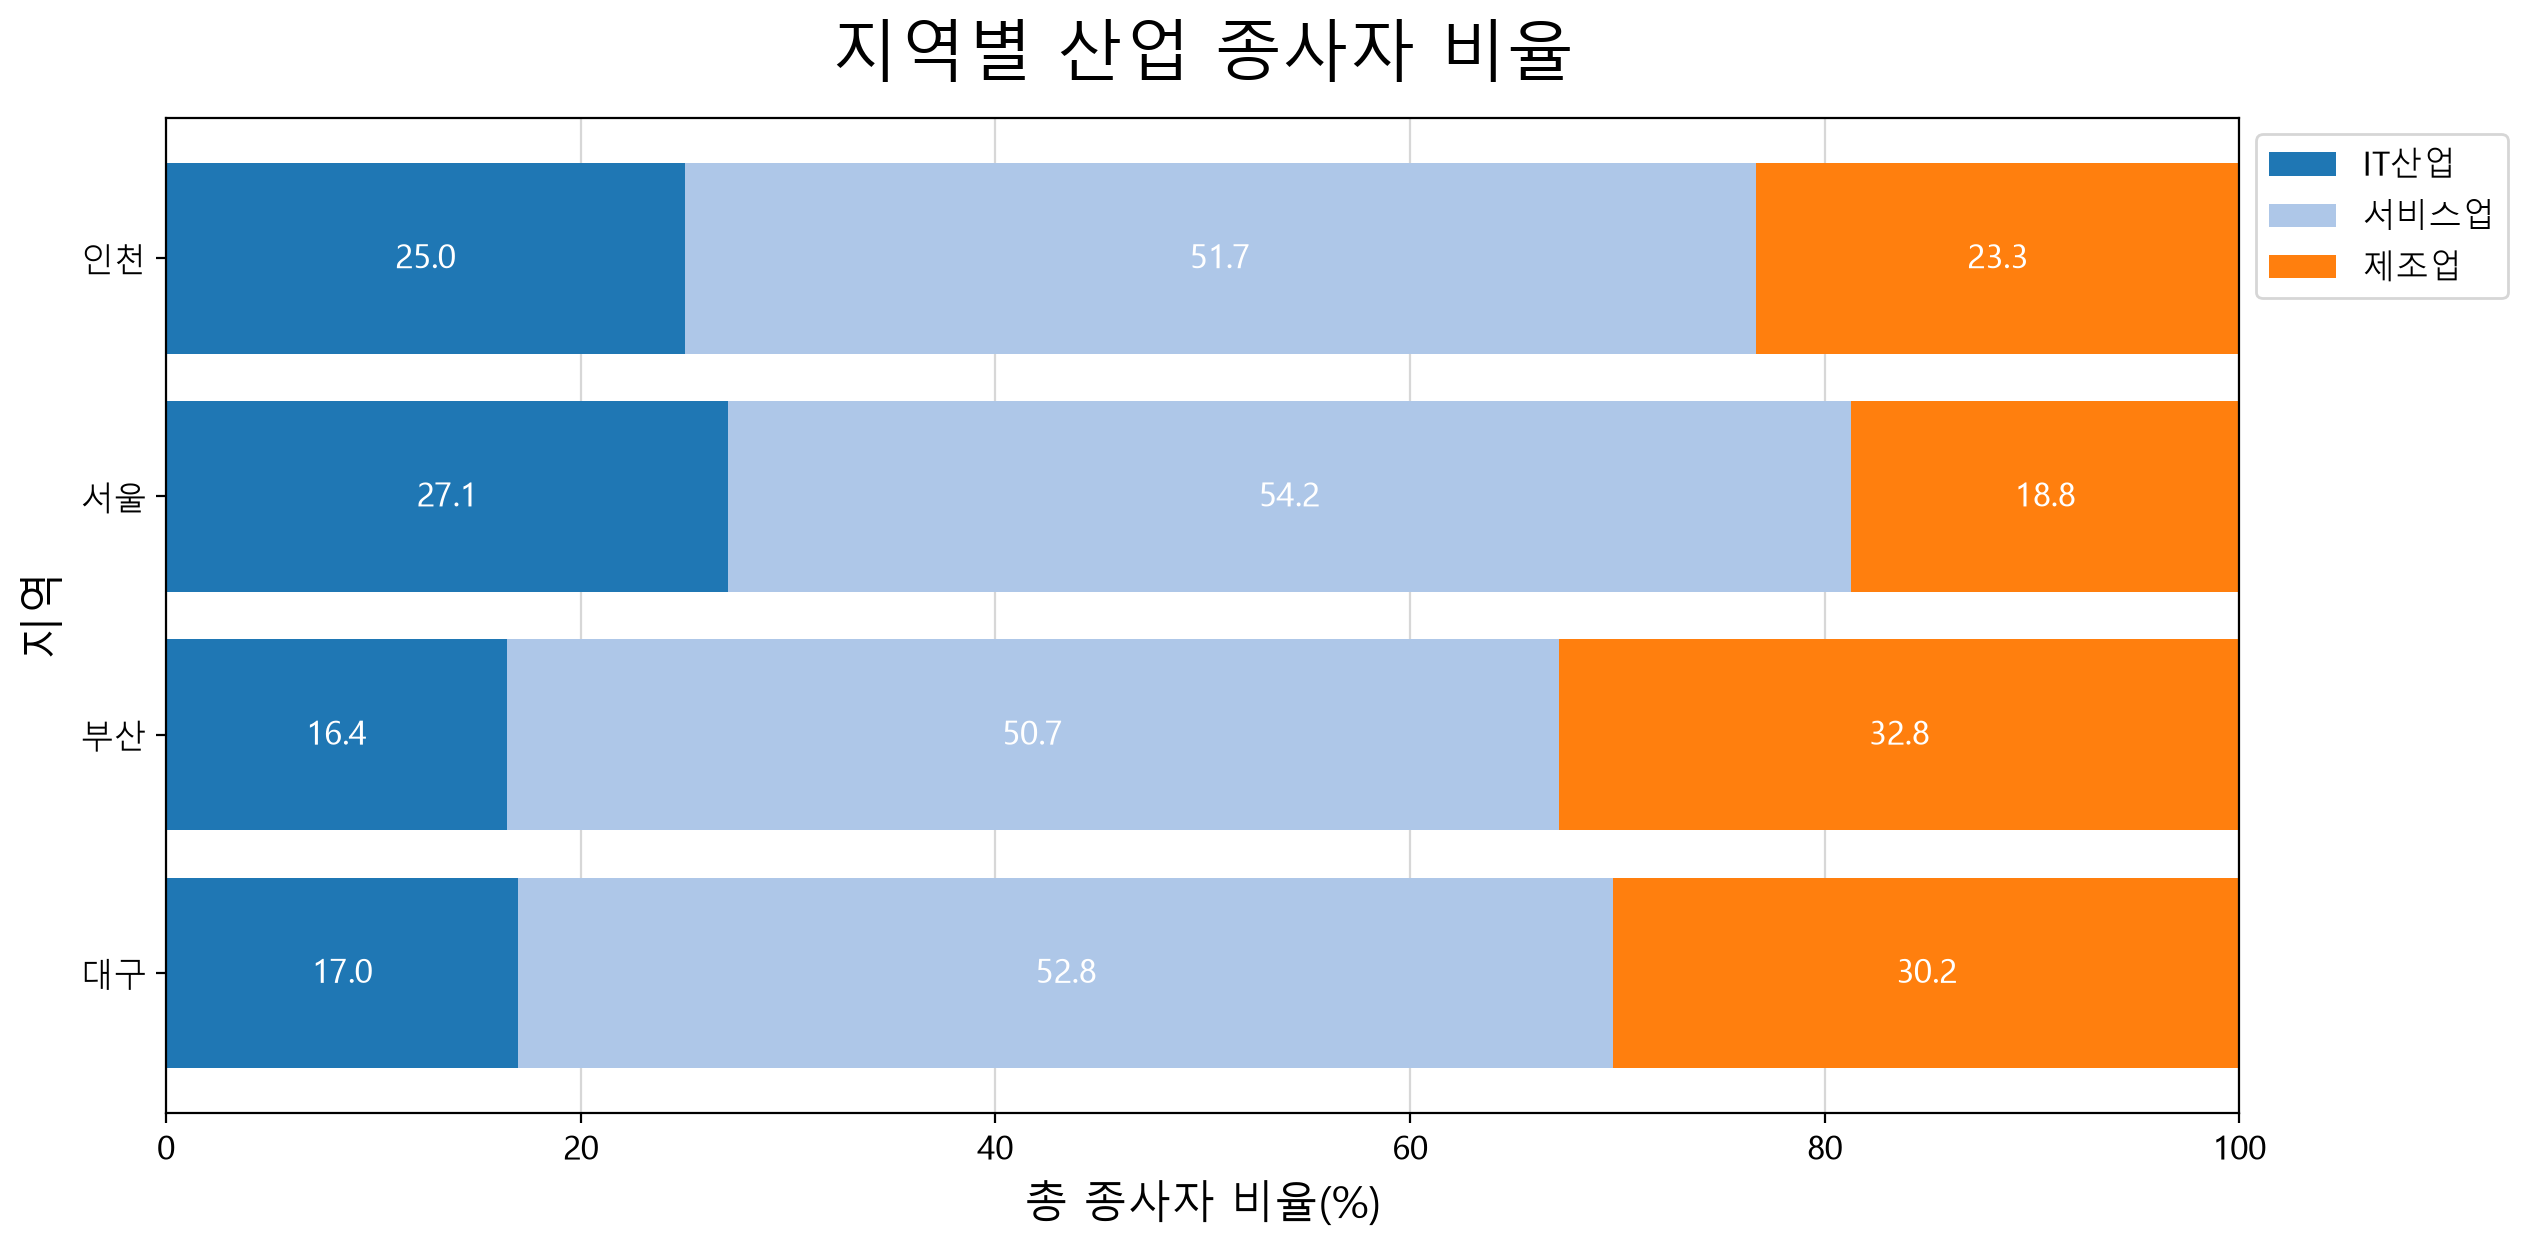

In [9]:
my_plot.stackplot(data=origin, x="지역", y="종사자 수", hue="산업", 
                  aggfunc=np.sum, orient='h', ratio=True, palette="tab20",
                  title="지역별 산업 종사자 비율", xlabel="총 종사자 비율(%)", ylabel="지역")

## #01. 연습문제 - 결제 수단을 통한 소비 트렌드 읽기 

### 1. 라이브러리 불러오기 

In [13]:
from jussam import load_data
from helpers import *
from pandas import pivot_table, melt
import seaborn as sb
import numpy as np

### 2. 데이터 셋 불러오기 

In [14]:
origin = load_data("payment_data")
origin

📚 2020~2024년도 기간동안 어느 커피숍의 결제 건수를 결제 수단별로 기록한 가상의 데이터


,현금,신용카드,모바일페이,상품권
연도,,,,
2020,4000,4000,1500,500
2021,3200,4300,2000,500
2022,2500,4500,2700,300
2023,1800,4400,3500,300
2024,1000,4200,4500,300


In [ ]:
# 연도가 index에 있으니까, 값으로 쓰려면 인덱스를 해제해야 겠구나. 

In [17]:
df1 = origin.reset_index()
df1

,연도,현금,신용카드,모바일페이,상품권
0,2020,4000,4000,1500,500
1,2021,3200,4300,2000,500
2,2022,2500,4500,2700,300
3,2023,1800,4400,3500,300
4,2024,1000,4200,4500,300


In [19]:
df2 = melt(df1, 
          id_vars="연도", 
          var_name="결제수단",
          value_name="건수"
          )
df2

,연도,결제수단,건수
0,2020,현금,4000
1,2021,현금,3200
2,2022,현금,2500
3,2023,현금,1800
4,2024,현금,1000
5,2020,신용카드,4000
6,2021,신용카드,4300
7,2022,신용카드,4500
8,2023,신용카드,4400
9,2024,신용카드,4200


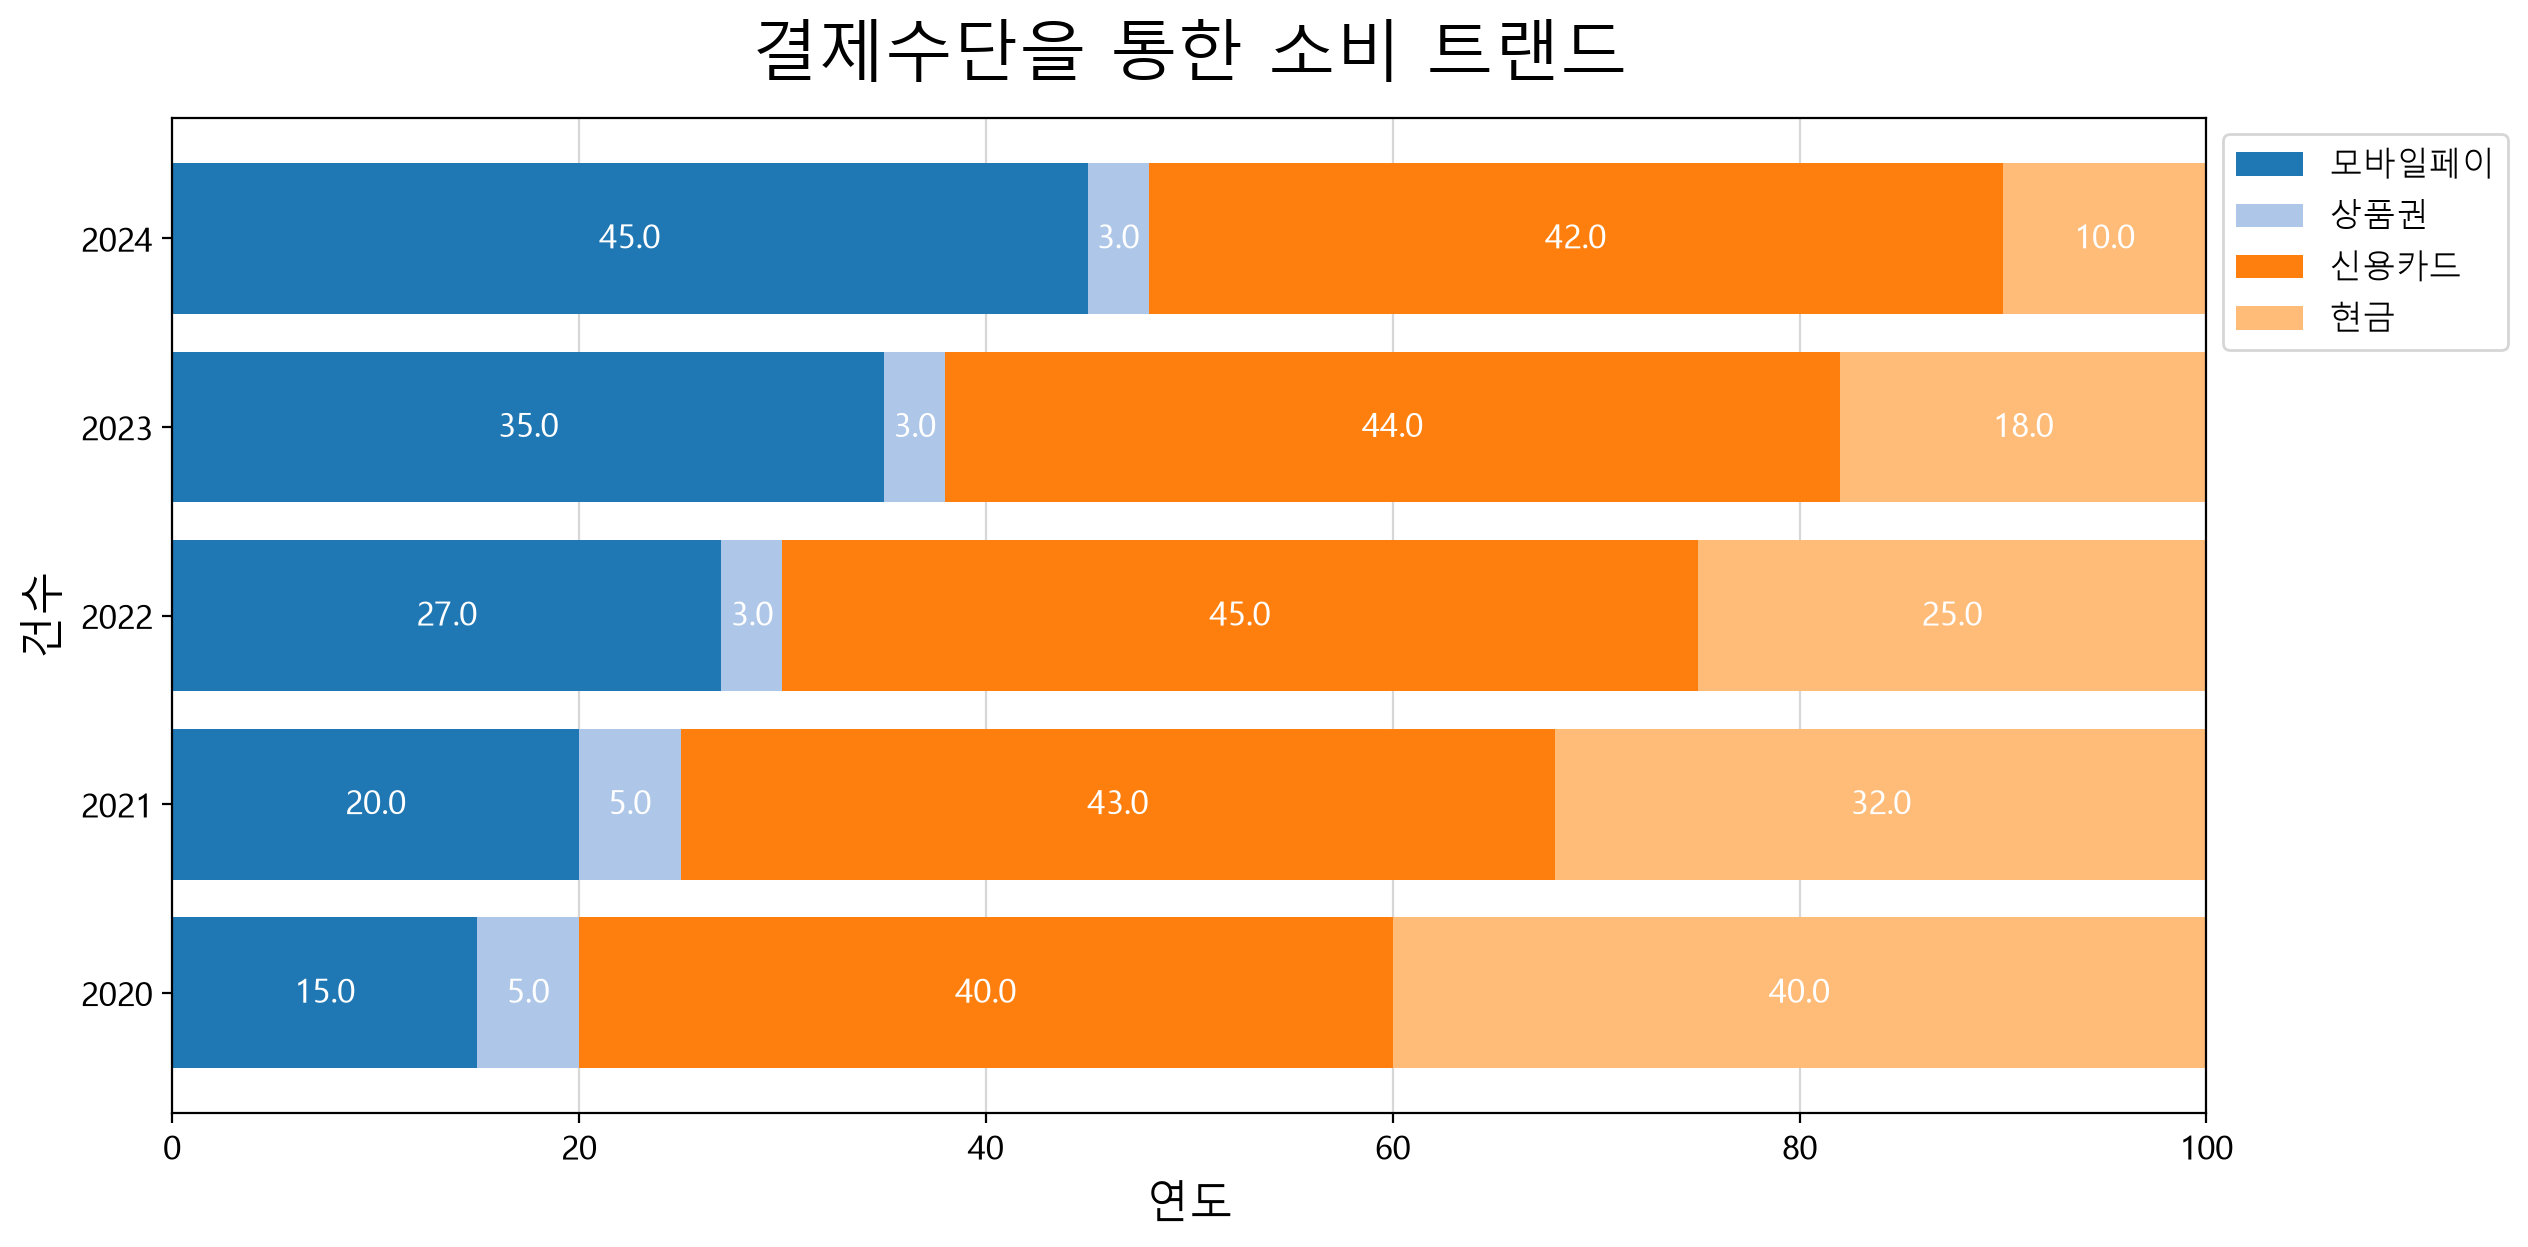

In [21]:
my_plot.stackplot(data=df2, x="연도", y="건수", hue="결제수단", 
                  aggfunc=np.sum, orient='h', ratio=True, palette="tab20",
                  title="결제수단을 통한 소비 트랜드", xlabel="연도", ylabel="건수")